In [4]:
df['cdc_report_dt'] = pd.to_datetime(df['cdc_report_dt'], errors='coerce')

daily_cases = df.groupby('cdc_report_dt').size().reset_index(name='cases')

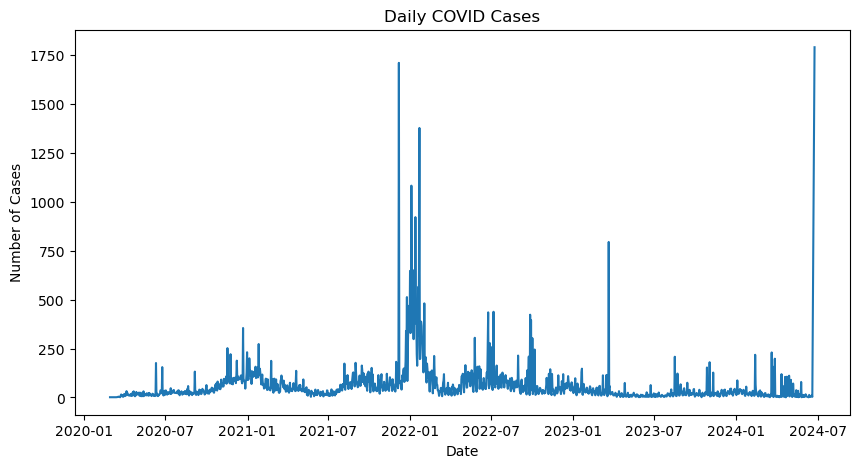

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(daily_cases['cdc_report_dt'], daily_cases['cases'])
plt.title("Daily COVID Cases")
plt.xlabel("Date")
plt.ylabel("Number of Cases")
plt.show()

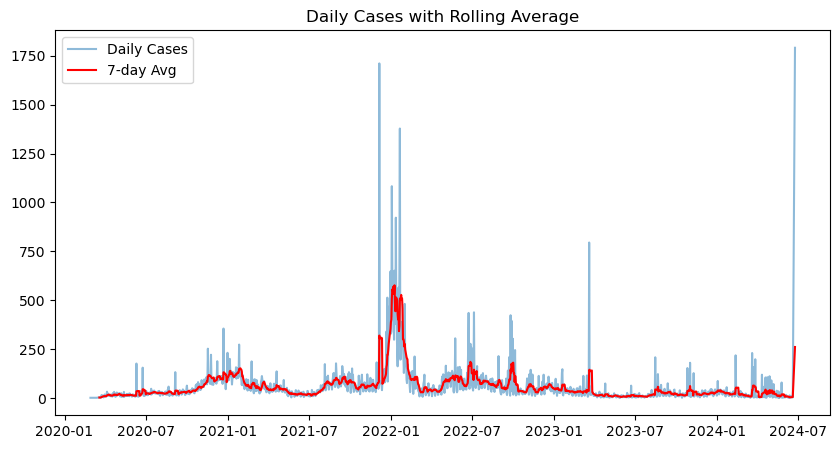

In [6]:
daily_cases['rolling_avg'] = daily_cases['cases'].rolling(window=7).mean()

plt.figure(figsize=(10,5))
plt.plot(daily_cases['cdc_report_dt'], daily_cases['cases'], alpha=0.5, label='Daily Cases')
plt.plot(daily_cases['cdc_report_dt'], daily_cases['rolling_avg'], color='red', label='7-day Avg')
plt.title("Daily Cases with Rolling Average")
plt.legend()
plt.show()

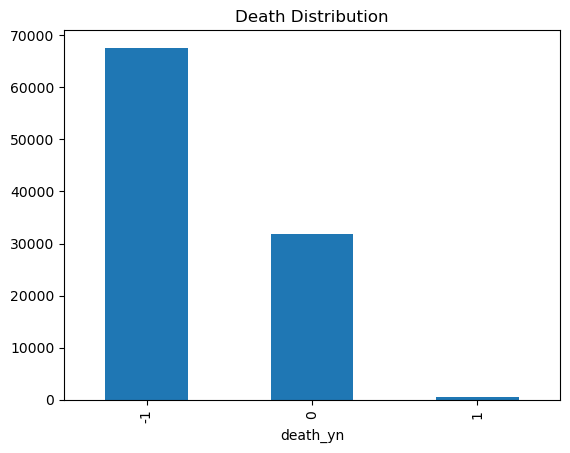

In [7]:
df['death_yn'].value_counts().plot(kind='bar', title='Death Distribution')
plt.show()

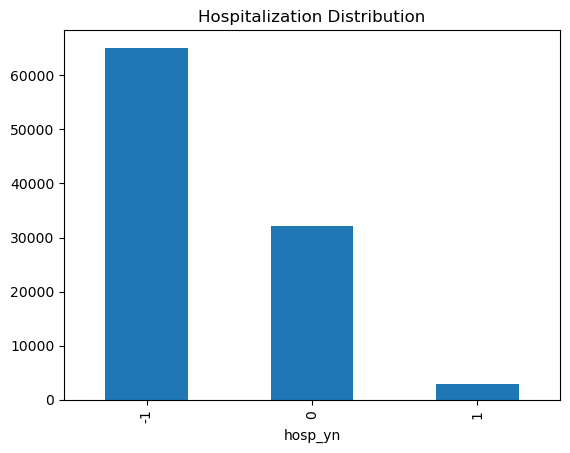

In [8]:
df['hosp_yn'].value_counts().plot(kind='bar', title='Hospitalization Distribution')
plt.show()

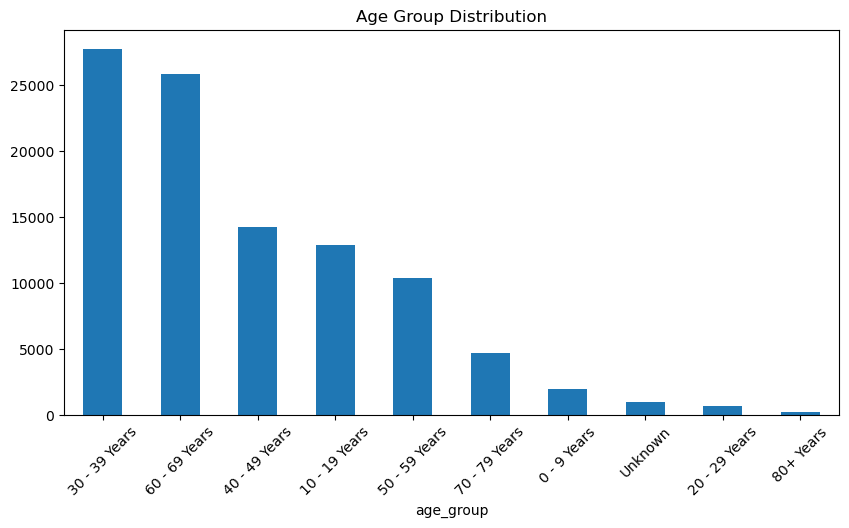

In [9]:
df['age_group'].value_counts().plot(kind='bar', title='Age Group Distribution', figsize=(10,5))
plt.xticks(rotation=45)
plt.show()

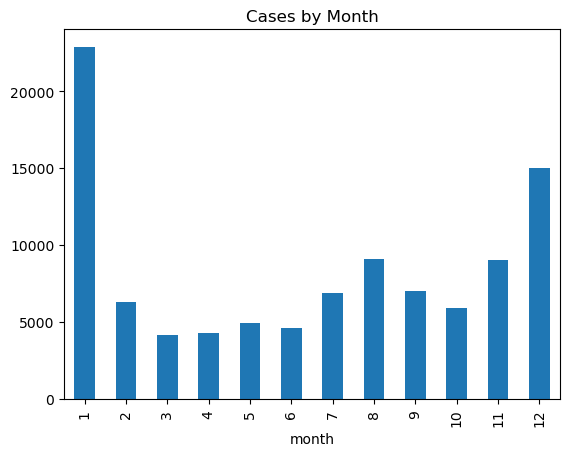

In [11]:
monthly_cases = df.groupby('month').size()

monthly_cases.plot(kind='bar', title='Cases by Month')
plt.show()

## Exploratory Analysis and Feature Preparation

### 1. Time-Series Analysis

A time-series plot of daily COVID-19 cases was generated using the reporting date (`cdc_report_dt`). The visualization reveals clear fluctuations in case counts over time, with notable peaks during major outbreaks.

To better understand trends, a 7-day rolling average was computed and displayed alongside daily case counts. The rolling average smooths out short-term fluctuations and emphasizes overall trends in the data.

The time-series analysis shows:

* Major peaks around 2021–2022
* Sudden spikes suggesting potential anomalies
*Periods of stability followed by sharp increases

---

### 2. Case Distribution Analysis

Distribution plots were generated for key variables to understand data patterns:

* **Death Distribution (`death_yn`):**
  Most cases are labeled "No" or "Missing," with very few deaths. This shows a significant class imbalance in mortality data.

* **Hospitalization Distribution (`hosp_yn`):**
  The majority of cases are not hospitalized, and many values are missing, reflecting real-world reporting limitations.

* **Age Group Distribution:**
  Most cases are from adult age groups, especially 30–39 and 60–69 years, indicating higher reporting in these categories.

---

### 3. Monthly Case Trends

Cases were grouped by month to identify seasonal patterns. The visualization reveals fluctuations in case numbers across different months, indicating waves of infection and possible seasonal influences.

---

### 4. Insights for Anomaly Detection

The visualizations highlight several key patterns:

* Sharp increases in daily cases, pointing to potential anomalies
* Pronounced imbalance in outcome variables like death and hospitalization
* Temporal trends that suggest outbreak waves

These insights confirm that the dataset is suitable for anomaly detection and support the use of models like Isolation Forest, Local Outlier Factor, and One-Class SVM in later analysis.

---

## Summary

Exploratory visualizations were developed to better understand temporal trends and data distributions. These visual insights offer a deeper understanding of the dataset and aid in feature preparation for anomaly detection models.
